<a href="https://colab.research.google.com/github/deepkkumar07/Machine-Learning-Projects/blob/main/Supervised_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from  sklearn.linear_model import LogisticRegression

In [3]:
df = pd.read_csv('/content/drive/MyDrive/machine learning/WA_Fn-UseC_-Telco-Customer-Churn.csv')


**What is churn prediction**


Churn Prediciton is analytical studies on the possibility of a customer abandoning a product or service. The goal is to understand and take step to change it before customers gives up the product service.

**churn = (Customers Lost ÷ Customers at Start of Period) × 100**

# About Dataset
1. customerID : customer_id
2. gender : weather customer si male or female
3. Senior Citezen : Weather customer si senior citezen or not(1,0)
4. Partener : Customer has a partener or not?? (Yes, No)
5. Dependent : Wheter the customer has dependents or not(Yes, No)
6. tenure : Number of months customer has stayed eith comapny
7. Phone service : Wheter the customer has a phone service or not??(Yes NO)
8. Internet service: Customers internet service provider (DSL, Fibe Optics,NO)
9. Online security : wheter customer has onlinesecurity or no t
10. online backup : customer has online backup or not(Yes, NO, No internet service)
11. Monthly charges : The amount charged to the customer monthly
12. Total Charges : The amount charged to the customers
13. churn : whether the customer churned or not


In [4]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [6]:
df.tail(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [9]:
df['TotalCharges'].value_counts().tail()

,count
TotalCharges,
130.15,1
3211.9,1
7843.55,1
2196.3,1
197.4,1


In [10]:
df[df['TotalCharges'].str.strip() == '']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [11]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [12]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [13]:
df['TotalCharges'].dropna(inplace=True)

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


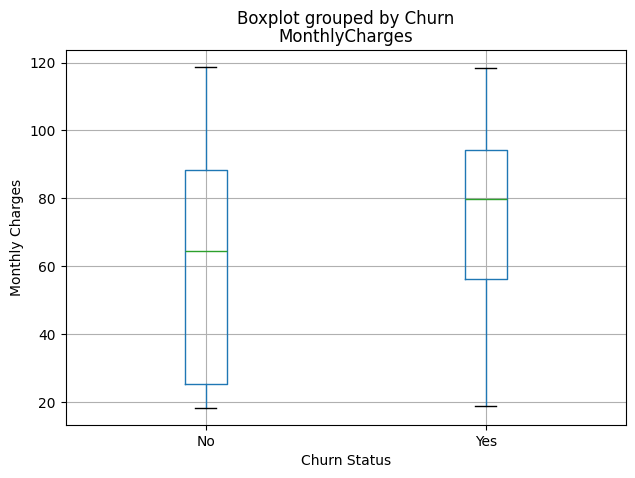

In [15]:
fig = plt.figure(figsize=(7,5))
ax=fig.gca()
df.boxplot(column = 'MonthlyCharges', by  = 'Churn', ax= ax)
ax.set_ylabel("Monthly Charges")
ax.set_xlabel("Churn Status")
plt.show()


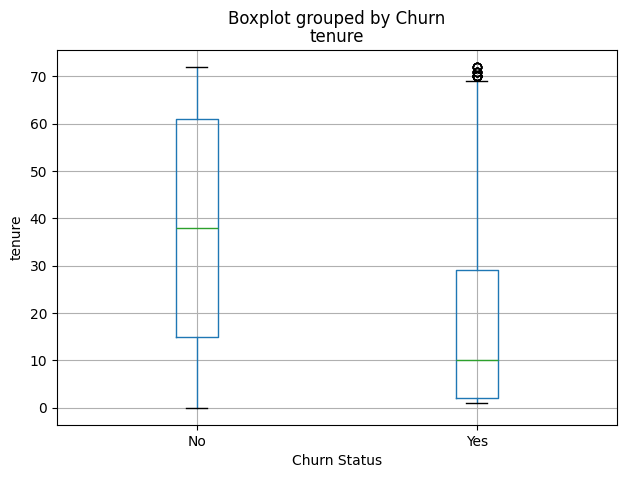

In [16]:
fig = plt.figure(figsize=(7,5))
ax=fig.gca()
df.boxplot(column = 'tenure', by  = 'Churn', ax= ax)
ax.set_ylabel("tenure")
ax.set_xlabel("Churn Status")
plt.show()

In [17]:
# function to convert churn into 0 and 1

def convert_churn(churn):
  if churn == 'Yes':
    return 1
  else:
    return 0


In [18]:
df['Churn'] = df['Churn'].apply(convert_churn)

In [19]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [20]:
x = df[['tenure', 'MonthlyCharges']].copy()
y = df['Churn'].copy()

In [21]:
df.shape

(7043, 21)

# FITTING LOGISTIC REGRESSION ON TRAIN DATA

In [22]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=42)
print(x_train.shape)
print(x_test.shape)


(5634, 2)
(1409, 2)


In [23]:
from sklearn.linear_model import LogisticRegression # Gradiant descent and seggmoid function, threshold

clf = LogisticRegression() # instance of the class , panlty = l2  parameter for overfitting CLF- CLIASIFIER MODEL
clf.fit(x_train, y_train) # .fit to train oon x train data thinkin gtarget is y train


LogisticRegression()

In [24]:
print(clf.coef_)
print(clf.intercept_)

[[-0.05347227  0.03197007]]
[-1.76053843]


In [25]:
# get the predicteed probability(0.90 -->class 1 , 0.2 --> class 0)

train_prediction = clf.predict_proba(x_train)
test_prediction = clf.predict_proba(x_test)

In [26]:
# get the prdicted classed
train_classes = clf.predict(x_train) # compare with y train - hopw good the trining has been done
test_classes = clf.predict(x_test)# compare with y test - how good the trainde model perform on unseen dataset


In [27]:
train_prediction

array([[0.69215153, 0.30784847],
       [0.82354473, 0.17645527],
       [0.74351383, 0.25648617],
       ...,
       [0.84890503, 0.15109497],
       [0.31491988, 0.68508012],
       [0.92538098, 0.07461902]])

In [28]:
train_classes

array([0, 0, 0, ..., 0, 1, 0])

In [38]:
from sklearn.metrics import accuracy_score
test_accuracy =  accuracy_score(y_test, test_classes)#y_test is the actual value i.e 20 % values of churn or not , testclass - value that model predicted
print("the accuracy of the model is: ", test_accuracy)

the accuracy of the model is:  0.7977288857345636


In [39]:
accuracy_score(y_train, train_classes) # how good i i have learned

0.7822151224707136

In [40]:
!git clone https://github.com/deepkkumar07/Machine-Learning-Projects.git

Cloning into 'Machine-Learning-Projects'...
fatal: could not read Username for 'https://github.com': No such device or address


In [42]:
!git clone https://github.com/deepkkumar07/Machine-Learning-Projects.git

Cloning into 'Machine-Learning-Projects'...
remote: Enumerating objects: 3, done.
remote: Counting objects: 100% (3/3), done.
remote: Total 3 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (3/3), done.


In [44]:
%cd /content/Machine-Learning-Projects

/content/Machine-Learning-Projects


In [45]:
!pwd

/content/Machine-Learning-Projects


In [49]:
!ls

01_Churn_Prediction_Logistic_Regression  README.md


In [47]:
!git config --global user.name "Deepak Kumar"
!git config --global user.email "deepk.kumar286@gmail.com"

In [48]:
!mkdir 01_Churn_Prediction_Logistic_Regression

In [50]:
from google.colab import _message

notebook = _message.blocking_request('get_ipynb', request='1')